# Dados


In [81]:
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.preprocessing import add_dummy_feature
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [82]:
np.random.seed(42)

m = 1000
X = np.random.rand(m,1)
y = 0.85 * X + 2 + np.random.rand(m,1)

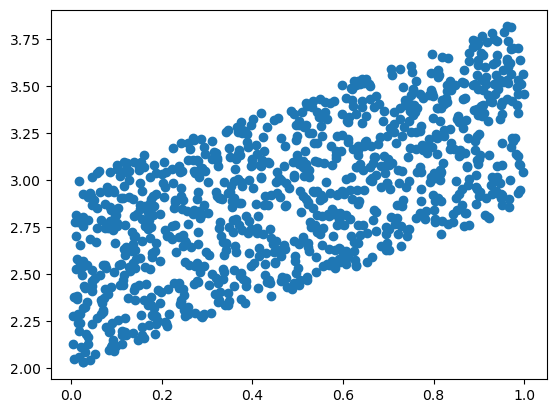

In [83]:
plt.scatter(X, y)
plt.show()

In [84]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [85]:
X_test = add_dummy_feature(X_test)
X_train = add_dummy_feature(X_train)
X_plot = add_dummy_feature(X)

A célula acima faz uma cópia do vetor $\mathbf x$, fazendo com que o $\mathbf{X_0}$ seja sempre 1, para que não altere o valor do viés ($\mathbf{\theta_0}$)

# Model

## Using Normal Equation

$$\hat {\boldsymbol{\theta}} = (\mathbf{X^T} \mathbf{X})^{-1} \mathbf{X^T} y$$

In [86]:
class NormalEquation():
    def __init__(self):
        self.intercept_ = None
        self.coef_ = None
    
    def fit(self, X, y):
        self.intercept_, self.coef_ = np.linalg.inv(X.T @ X) @ X.T @ y
        return self.intercept_, self.coef_
    
    def predict(self, X): 
        theta = np.hstack((self.intercept_, self.coef_))
        return X @ theta.T

In [87]:
normal_model = NormalEquation()

In [88]:
normal_model.fit(X_train, y_train)

(array([2.48920496]), array([0.90597912]))

In [89]:
y_pred = normal_model.predict(X_test)

## Gradient Descent

$$\frac{\partial}{\partial \theta_j} = 
\frac2m \sum\limits_{i=1}^m \ (\boldsymbol{\theta^T}\mathbf{x}^{(i)} - y^{(i)})  x_j^{(i)}$$

$$\nabla_{\boldsymbol{\theta}} = 
\begin{pmatrix}
    \frac{\partial}{\partial \theta_0} \\
    \frac{\partial}{\partial \theta_1} \\
    \vdots \\
    \frac{\partial}{\partial \theta_n}
\end{pmatrix} 
= \frac{2}{m} \mathbf{X}^{T} (\mathbf{X} \boldsymbol{\theta} - \mathbf{y})$$

$$\boldsymbol{\theta}^{\text{(next step)}} = \boldsymbol{\theta} - \eta \nabla_{\boldsymbol{\theta}}$$

### Using Batch Gradient 

In [90]:
class BatchGradient():
    def __init__(self):
        np.random.seed(42)
        self.theta = np.random.rand(2, 1)

    def fit(self, X, y, eta=0.1, n_epochs=1000):
        m = len(X)

        for epoch in range(n_epochs):
            gradients = (2 / m) * X.T @ (X @ self.theta - y)
            self.theta = self.theta - eta * gradients
        return self.theta

    def predict(self, X): 
        theta = np.hstack((self.theta ))
        return X @ theta.T

In [91]:
batch_model = BatchGradient()

In [92]:
batch_model.fit(X_train, y_train)

array([[2.48920441],
       [0.90598017]])

In [93]:
y_pred_batch = batch_model.predict(X_test)

### Using Stochastic Gradient

In [94]:
class StochasticGradient():
    def __init__(self):
        np.random.seed(42)
        self.theta = np.random.rand(2, 1)
        self.t0, self.t1 = 5,50
    
    def __learning_schedule(self, t):
        return self.t0 / (t + self.t1)

    def fit(self, X, y, eta=0.01, n_epochs=50):
        m = len(X)

        for epoch in range(n_epochs):
            for iteration in range(m):
                random_index = np.random.randint(m)

                x_i = X[random_index : random_index + 1]
                y_i = y[random_index : random_index + 1]

                gradients =  2 * x_i.T @ (x_i @ self.theta - y_i)
                eta = self.__learning_schedule(epoch * m + iteration)
                self.theta = self.theta - eta * gradients
        return self.theta

    def predict(self, X): 
        theta = np.hstack((self.theta))
        return X @ theta.T

In [95]:
stochastic_model = StochasticGradient()

In [96]:
stochastic_model.fit(X_train, y_train)

array([[2.48552923],
       [0.91430195]])

In [97]:
y_pred_stoch = stochastic_model.predict(X_test)

# Comparando com `scikit-learn`

In [98]:
sk_model = LinearRegression()

In [99]:
sk_model.fit(X_train, y_train)

LinearRegression()

In [100]:
y_pred_sk = sk_model.predict(X_test)

In [101]:
print(f'Normal Equation: \n Bias: {normal_model.fit(X_train, y_train)[0]} \t Weight: {normal_model.fit(X_train, y_train)[1]}')
print(f'Batch Gradient: \n Bias: {batch_model.fit(X_train, y_train)[0]} \t Weight: {batch_model.fit(X_train, y_train)[1]}')
print(f'Stochastic Gradient: \n Bias: {stochastic_model.fit(X_train, y_train)[0]} \t Weight: {stochastic_model.fit(X_train, y_train)[1]}')
print(f'Scikit-Learn: \n Bias: {sk_model.intercept_} \t Weight: {sk_model.coef_}')

Normal Equation: 
 Bias: [2.48920496] 	 Weight: [0.90597912]
Batch Gradient: 
 Bias: [2.48920496] 	 Weight: [0.90597912]
Stochastic Gradient: 
 Bias: [2.49205211] 	 Weight: [0.90469928]
Scikit-Learn: 
 Bias: [2.48920496] 	 Weight: [[0.         0.90597912]]


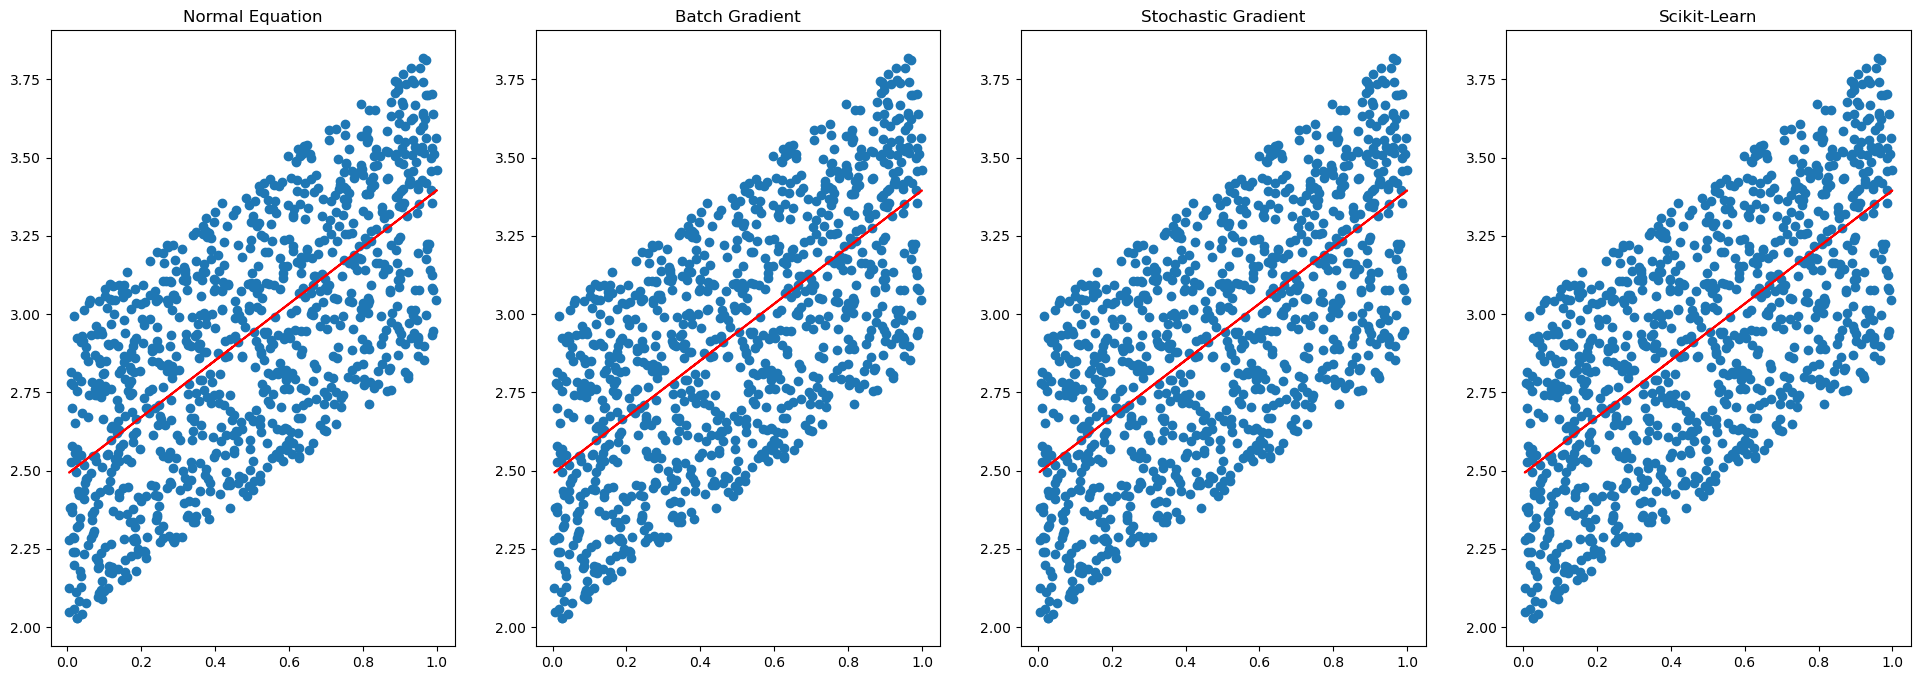

In [102]:
fig, axes = plt.subplots(1, 4, figsize=(24,8))

axes[0].plot(X, normal_model.predict(X_plot), 'r-')
axes[0].scatter(X, y)
axes[0].set_title('Normal Equation')

axes[1].plot(X, batch_model.predict(X_plot), 'r-')
axes[1].scatter(X, y)
axes[1].set_title('Batch Gradient')

axes[2].plot(X, stochastic_model.predict(X_plot), 'r-')
axes[2].scatter(X, y)
axes[2].set_title('Stochastic Gradient')

axes[3].plot(X, sk_model.predict(X_plot), 'r-')
axes[3].scatter(X, y)
axes[3].set_title('Scikit-Learn')

plt.show()